In [ ]:
# Imports
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing, decomposition
import scipy
from scipy.sparse import hstack
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier


In [ ]:
# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

# Handling Missing Values

In [ ]:
df = X.copy()
categorical_cols = ['job', 'marital', 'education', 'default', 'housing',
            'loan', 'contact', 'month', 'poutcome']
num_cols = ['age','balance','duration','campaign','pdays','previous']

# printing unknown rates
for i in categorical_cols:
  unknown_rate = (df[i].isna()).mean() * 100
  print(f"{i:10s}: {unknown_rate:.4f}%")

print("missing values in numeric before:".upper())
print(df[num_cols].isna().sum()) #no missing values in numerical columns so no need to fill in

for col in ['job', 'education']: #replace nan's with unknown as it should be according to the dataset description
    df[col] = df[col].fillna('unknown')

df['contact'] = df['contact'].fillna('none')
print("missing values in categorical after:".upper())
for i in categorical_cols:
  unknown_rate = (df[i].isna()).mean() * 100
  print(f"{i:10s}: {unknown_rate:.4f}%")

print("missing values in numeric after:".upper())
print(df[num_cols].isna().sum()) #no missing values in numerical columns so no need to fill in

df = df.drop(columns=['poutcome']) # drop poutcome since it is not important to teh dataset and missing a high number ov values



job       : 0.6370%
marital   : 0.0000%
education : 4.1074%
default   : 0.0000%
housing   : 0.0000%
loan      : 0.0000%
contact   : 28.7983%
month     : 0.0000%
poutcome  : 81.7478%
MISSING VALUES IN NUMERIC BEFORE:
age         0
balance     0
duration    0
campaign    0
pdays       0
previous    0
dtype: int64
MISSING VALUES IN CATEGORICAL AFTER:
job       : 0.0000%
marital   : 0.0000%
education : 0.0000%
default   : 0.0000%
housing   : 0.0000%
loan      : 0.0000%
contact   : 0.0000%
month     : 0.0000%
poutcome  : 81.7478%
MISSING VALUES IN NUMERIC AFTER:
age         0
balance     0
duration    0
campaign    0
pdays       0
previous    0
dtype: int64


# Convert Categorical attributes to numerical

In [ ]:
df = X.copy()

n = 10         # number of projected dimensions

# one-hot encode categorical attributes (removed poutcome)
cat_atts = ['job',
            'marital',
            'education',
            'default',
            'housing',
            'loan',
            'contact'
            ]

encs = dict()
cat_vectorized = dict()
for att in cat_atts:
  encs[att] = preprocessing.OneHotEncoder()
  cat_vectorized[att] = encs[att].fit_transform(df[att].to_frame())

# enumerate month attribute
months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
         'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month = df['month']
for num, name in enumerate(months):
  month = month.map(lambda x: num if x == name else x)


In [ ]:
class bank_data:
  cols = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y']

  def __init__(self, data):
    if (data.keys() != self.cols):
      raise Exception("Incorrect formatting")
    self.values = data.copy()

  def data_to_vector(self, data, cat_encoding, normalizers):
    # transforms banking data into its vectorized form
    return 0

  def get_y_outcome(self):
      return self.values['y']


# Feature Selection

In [ ]:
df = X.copy()

X_fs = df.copy()
y_fs = y.copy().values.ravel()

# one-hot encode categorical variables again for feature selection
X_encoded = pd.get_dummies(X_fs, drop_first=True)

k = 15  # number of top features
selector = SelectKBest(score_func=mutual_info_classif, k=k)
selector.fit(X_encoded, y_fs)

# get the selected features and their scores
selected_features = X_encoded.columns[selector.get_support()]
feature_scores = selector.scores_[selector.get_support()]

# show results sorted by score
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Score': feature_scores
}).sort_values(by='Score', ascending=False)

print(feature_importance)

X_selected = selector.transform(X_encoded)


                Feature     Score
3              duration  0.070961
14     poutcome_success  0.026397
4                 pdays  0.025719
1               balance  0.022602
10          housing_yes  0.013819
0                   age  0.012953
5              previous  0.012784
12            month_may  0.009080
7       marital_married  0.008920
11            month_mar  0.008586
2           day_of_week  0.006498
9    education_tertiary  0.005416
13            month_sep  0.005347
6       job_blue-collar  0.005317
8   education_secondary  0.004443


# Split into Train and Test Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_fs, test_size=0.2, random_state=42, stratify=y_fs
)

# Handle class imbalance with SMOTE

In [ ]:
print("Before balancing:", Counter(y_train))

sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

print("After balancing:", Counter(y_train_balanced))

Before balancing: Counter({'no': 31937, 'yes': 4231})
After balancing: Counter({'no': 31937, 'yes': 31937})


# Train a Decision Tree Model

In [ ]:
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,               # limit depth to prevent overfitting
    min_samples_split=50,      # avoid splitting on very small subsets
    min_samples_leaf=20,       # ensure leaves have enough samples
    random_state=42
)

# Fit model
dt_model.fit(X_train_balanced, y_train_balanced)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=20,
                       min_samples_split=50, random_state=42)

# Evaluate the Model

Decision Tree Performance:

Accuracy: 0.7685502598695123

Classification Report:
               precision    recall  f1-score   support

          no      0.957     0.773     0.855      7985
         yes      0.300     0.735     0.426      1058

    accuracy                          0.769      9043
   macro avg      0.628     0.754     0.641      9043
weighted avg      0.880     0.769     0.805      9043



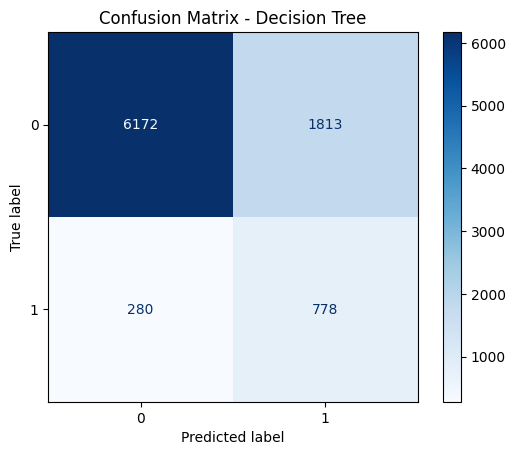

In [ ]:
# predictions
y_pred = dt_model.predict(X_test)

# evaluation metrics
print("Decision Tree Performance:\n")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# Train ADABoost

In [ ]:
# boosting algorithm

# base (weak) learner
base_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)

# AdaBoost model
ada_model = AdaBoostClassifier(
    estimator=base_tree,     # the weak learner
    n_estimators=300,        # number of trees
    learning_rate=0.5,       # smaller = slower learning but more stable
    random_state=42
)

# train the model
ada_model.fit(X_train_balanced, y_train_balanced)


AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                    max_depth=3,
                                                    random_state=42),
                   learning_rate=0.5, n_estimators=300, random_state=42)

# Evaluate the Model (ADABoost)



AdaBoost Performance:

Accuracy: 0.8417560544067234

Classification Report:
               precision    recall  f1-score   support

          no      0.948     0.868     0.906      7985
         yes      0.392     0.642     0.487      1058

    accuracy                          0.842      9043
   macro avg      0.670     0.755     0.697      9043
weighted avg      0.883     0.842     0.857      9043



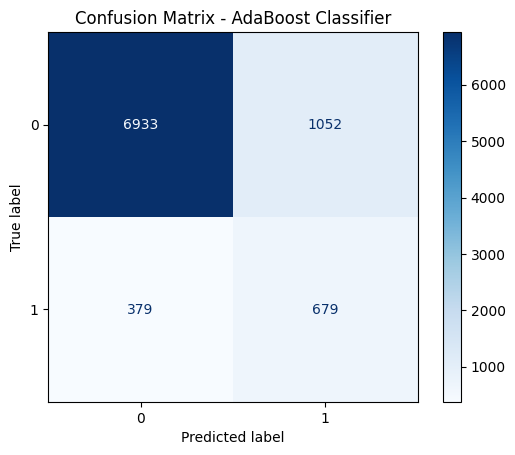

In [ ]:
# predictions
y_pred = ada_model.predict(X_test)

# evaluation metrics
print("AdaBoost Performance:\n")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - AdaBoost Classifier")
plt.show()


# Train XG

In [ ]:
#preliminary XG
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_balanced)
y_test_encoded = le.transform(y_test)
xgb_model.fit(X_train_balanced, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

# Evaluate the Model

Accuracy: 0.8515979210439013

Classification Report:
               precision    recall  f1-score   support

           0      0.952     0.876     0.912      7985
           1      0.416     0.668     0.513      1058

    accuracy                          0.852      9043
   macro avg      0.684     0.772     0.713      9043
weighted avg      0.890     0.852     0.866      9043



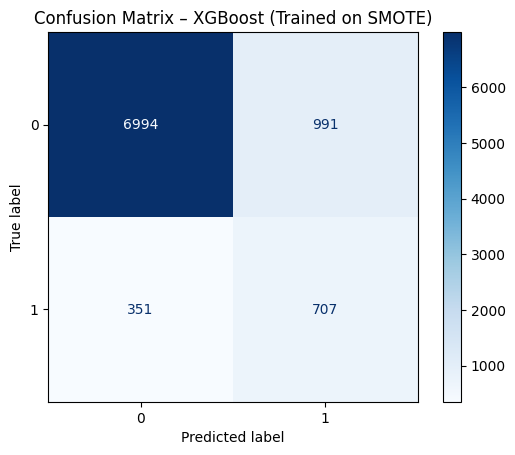

In [ ]:
#preliminary evaluation
y_pred_xgb = xgb_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test_encoded, y_pred_xgb, digits=3))

cm = confusion_matrix(y_test_encoded, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')co
plt.title("Confusion Matrix – XGBoost (Trained on SMOTE)")
plt.show()
